In [47]:
%load_ext autoreload
%autoreload 2

from blochK import Hamiltonian2D
import numpy as np
from numpy import pi,cos,sin,exp

import matplotlib.pyplot as plt
import matplotlib

from blochK.plotting.utils import extent #for getting the correct extent


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## The model of the p-wave paper

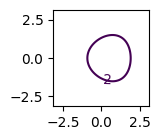

(2, 187)


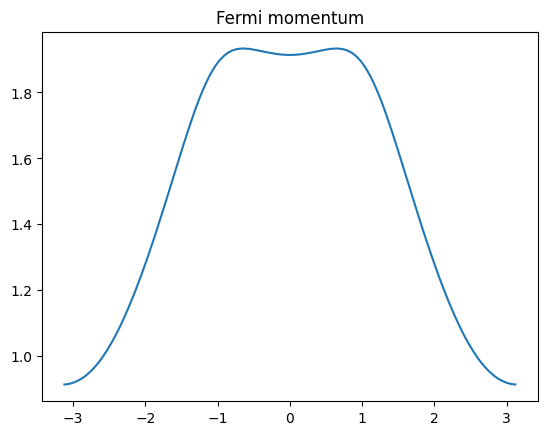

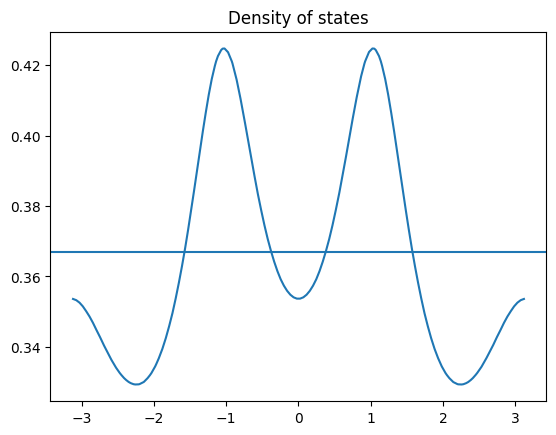

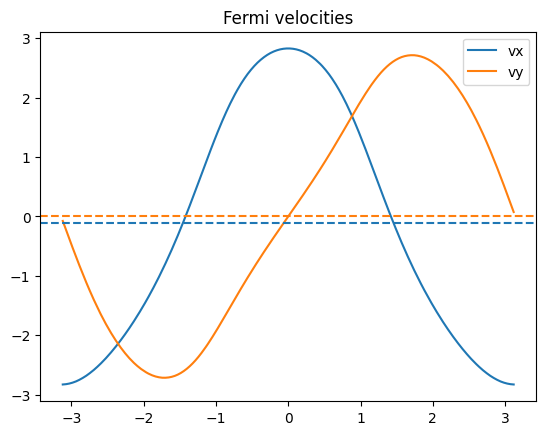

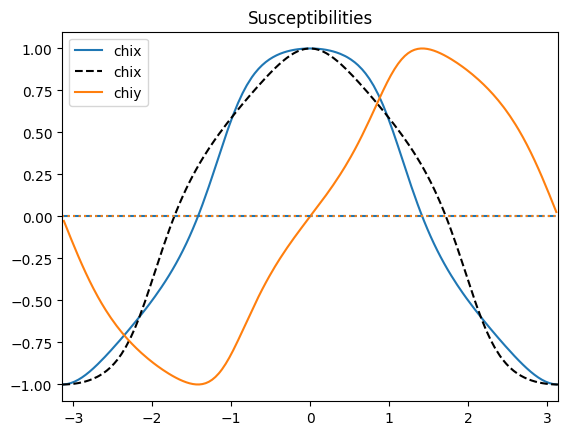

In [ ]:
from blochK.FermiSurface import get_points_FS,line_integration


def Ek_fct(kx,ky, k0=0.5,a=1,mu=0):
    """Dispersion relation of a 2D free electron gas shifted by k0."""
    return np.array([(kx - k0)**2 + (ky)**2 * (1-2*a*kx)])-mu

def vk_fct(kx,ky, k0=0.5,a=1,mu=0):
    """Velocity relation of a 2D free electron gas shifted by k0."""
    vx = 2*(kx - k0) - 2*a*ky**2
    vy = 2*ky*(1 - 2*a*kx)
    return np.array([[vx,vy]])


Eargs = dict(k0=0.5,a=0.1)

ps = get_points_FS(Ek_fct,show=True,Eargs=Eargs,mus=[2]) # list of bands, list of mus, list of segments, points, x and y components(2)


pointsFS = ps[0][0][0]  # First band, first mu
print(pointsFS.shape)

thetas = np.arctan2(pointsFS[1], pointsFS[0]-Eargs['k0']) #parametrization angle around the midpoint
sort_indices = np.argsort(thetas)
thetas = thetas[sort_indices]
pointsFS = pointsFS[:, sort_indices]

lenFS = line_integration(pointsFS, np.ones(pointsFS.shape[1]))

vs = vk_fct(pointsFS[0], pointsFS[1], **Eargs)[0]
dos = 1/(vs[0]**2 + vs[1]**2)**0.5

fig, ax = plt.subplots()
ax.set_title('Fermi momentum')
plt.plot(thetas,np.linalg.norm(pointsFS, axis=0), '-')
fig, ax = plt.subplots()
ax.set_title('Density of states')
plt.plot(thetas,dos, '-')
ax.axhline(line_integration(pointsFS, dos)/lenFS)

fig, ax = plt.subplots()
ax.set_title('Fermi velocities')
plt.plot(thetas, vs[0], 'C0-', label='vx')
plt.plot(thetas, vs[1], 'C1-', label='vy')

vavg = line_integration(pointsFS, vs)/lenFS
ax.axhline(vavg[0], color='C0', linestyle='--')
ax.axhline(vavg[1], color='C1', linestyle='--')
plt.legend()


fig, ax = plt.subplots()
ax.set_title('Susceptibilities')
chis = vs*dos
plt.plot(thetas, chis[0], '-', label='chix')
plt.plot(thetas-np.pi, -chis[0], 'k--', label='chix')
plt.plot(thetas+np.pi, -chis[0], 'k--')
plt.plot(thetas, chis[1], '-', label='chiy')
chi_avg = line_integration(pointsFS, chis)/lenFS
ax.axhline(chi_avg[0], color='C0', linestyle='--')
ax.axhline(chi_avg[1], color='C1', linestyle=':')
ax.set_xlim(-pi, pi)
plt.legend()




## Our model

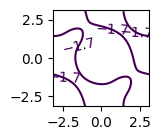

Segments found: 4
(2, 210)


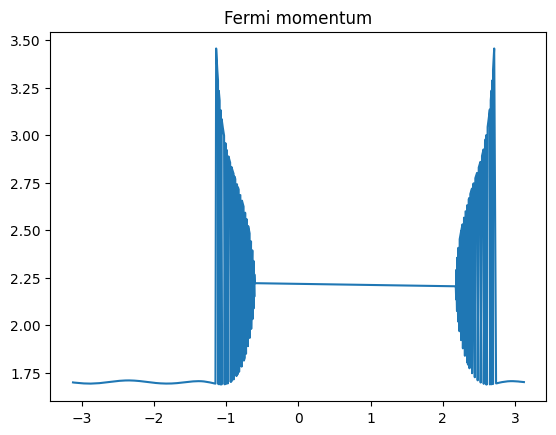

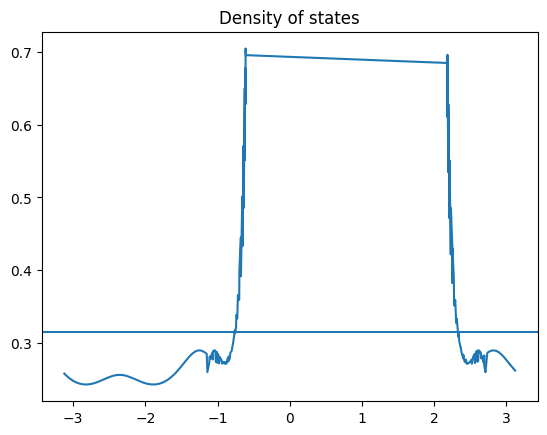

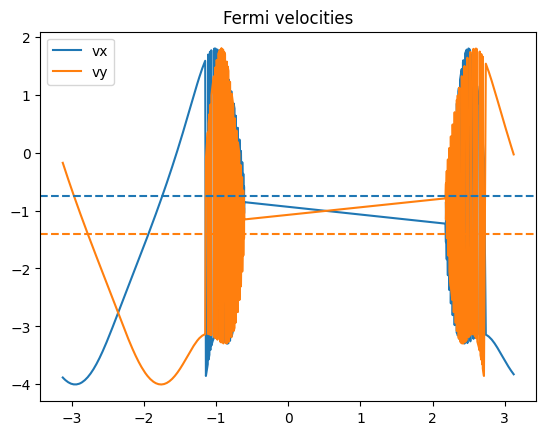

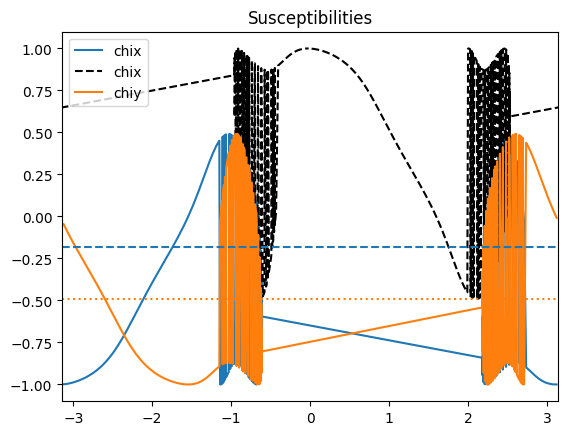

In [145]:
from blochK.FermiSurface import get_points_FS,line_integration


def Ek_fct(kx,ky, t=1,tp=0.5,m=0,z=0,mu=0):
    """Dispersion relation of a 2D free electron gas shifted by k0."""

    ek = -2*t*np.cos(kx)-2*t*np.cos(ky) -2*tp*(np.cos(kx+ky)+np.cos(kx-ky))
    ekQ = +2*t*np.cos(kx)+2*t*np.cos(ky) -2*tp*(np.cos(kx+ky)+np.cos(kx-ky))

    d0 = (ek + ekQ)/2 - mu
    dz = (ek - ekQ)/2
    dx = m + 2*z*sin(kx+ky)


    return np.array([d0 - (dx**2 + dz**2)**0.5])

def vk_fct(kx,ky, t=1,tp=0.5,m=0,z=0,mu=0):
    """Velocity relation of a 2D free electron gas shifted by k0."""
    ek = -2*t*np.cos(kx)-2*t*np.cos(ky) -2*tp*(np.cos(kx+ky)+np.cos(kx-ky))
    ekQ = +2*t*np.cos(kx)+2*t*np.cos(ky) -2*tp*(np.cos(kx+ky)+np.cos(kx-ky))

    d0 = (ek + ekQ)/2 - mu
    dz = (ek - ekQ)/2
    dx = m + 2*z*sin(kx+ky)

    #vx
    ek_dx = 2*t*sin(kx) + 2*tp*(sin(kx+ky)+sin(kx-ky)) 
    ekQ_dx = -2*t*sin(kx) + 2*tp*(sin(kx+ky)+sin(kx-ky))

    d0_dx = (ek_dx + ekQ_dx)/2
    dz_dx = (ek_dx - ekQ_dx)/2
    dx_dx = 2*z*cos(kx+ky)

    vx = d0_dx - (dx*dx_dx + dz*dz_dx)/(dx**2 + dz**2)**0.5

    #vy
    ek_dy = 2*t*sin(ky) + 2*tp*(sin(kx+ky)-sin(kx-ky))
    ekQ_dy = -2*t*sin(ky) + 2*tp*(sin(kx+ky)-sin(kx-ky))

    d0_dy = (ek_dy + ekQ_dy)/2
    dz_dy = (ek_dy - ekQ_dy)/2
    dx_dy = 2*z*cos(kx+ky)
    vy = d0_dy - (dx*dx_dy + dz*dz_dy)/(dx**2 + dz**2)**0.5

    return np.array([[vx,vy]])


Eargs = dict(z=0.9,m=0.9)
#,n1=[pi,pi],n2=[-pi,pi]
ps = get_points_FS(Ek_fct,show=True,Eargs=Eargs,mus=[-1.7]) # list of bands, list of mus, list of segments, points, x and y components(2)
print('Segments found:', len(ps[0][0]))

pointsFS = ps[0][0][0]  # First band, first mu
print(pointsFS.shape)

thetas = np.arctan2(pointsFS[1], pointsFS[0]-0) #parametrization angle around the midpoint
sort_indices = np.argsort(thetas)
thetas = thetas[sort_indices]
pointsFS = pointsFS[:, sort_indices]

lenFS = line_integration(pointsFS, np.ones(pointsFS.shape[1]))

vs = vk_fct(pointsFS[0], pointsFS[1], **Eargs)[0]
dos = 1/(vs[0]**2 + vs[1]**2)**0.5

fig, ax = plt.subplots()
ax.set_title('Fermi momentum')
plt.plot(thetas,np.linalg.norm(pointsFS, axis=0), '-')
fig, ax = plt.subplots()
ax.set_title('Density of states')
plt.plot(thetas,dos, '-')
ax.axhline(line_integration(pointsFS, dos)/lenFS)

fig, ax = plt.subplots()
ax.set_title('Fermi velocities')
plt.plot(thetas, vs[0], 'C0-', label='vx')
plt.plot(thetas, vs[1], 'C1-', label='vy')

vavg = line_integration(pointsFS, vs)/lenFS
ax.axhline(vavg[0], color='C0', linestyle='--')
ax.axhline(vavg[1], color='C1', linestyle='--')
plt.legend()


fig, ax = plt.subplots()
ax.set_title('Susceptibilities')
chis = vs*dos
plt.plot(thetas, chis[0], '-', label='chix')
plt.plot(thetas-np.pi, -chis[0], 'k--', label='chix')
plt.plot(thetas+np.pi, -chis[0], 'k--')
plt.plot(thetas, chis[1], '-', label='chiy')
chi_avg = line_integration(pointsFS, chis)/lenFS
ax.axhline(chi_avg[0], color='C0', linestyle='--')
ax.axhline(chi_avg[1], color='C1', linestyle=':')
ax.set_xlim(-pi, pi)
plt.legend()




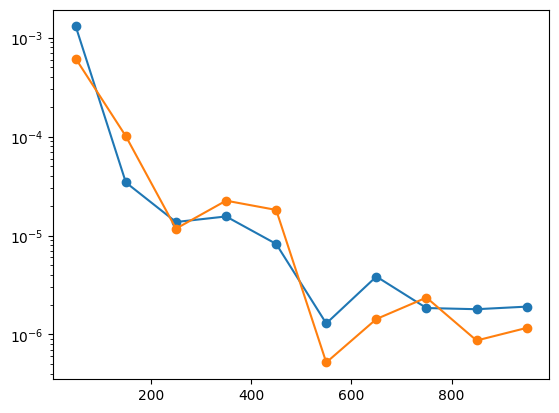

In [146]:
Lks = np.arange(50,1000,100)


chis = []
for Lk in Lks:
    ps = get_points_FS(Ek_fct,Eargs=Eargs,mus=[-1.8],n1=[pi,pi],n2=[-pi,pi],Lk=Lk) # list of bands, list of mus, list of segments, points, x and y components(2)

    chis_segment = []
    for pointsFS_segment in ps[0][0]: 
        vs = vk_fct(pointsFS_segment[0], pointsFS_segment[1], **Eargs)[0]
        chiks = ([vs[0]+vs[1],vs[0]-vs[1]])/(vs[0]**2 + vs[1]**2)**0.5
        chis_segment.append(line_integration(pointsFS_segment, chiks))
    chis.append(np.sum(chis_segment,axis=0))
chis = np.array(chis)

plt.plot(Lks, np.abs(chis)[:,0], 'o-', label='chix')
plt.plot(Lks, np.abs(chis)[:,1], 'o-', label='chiy')
plt.yscale('log')

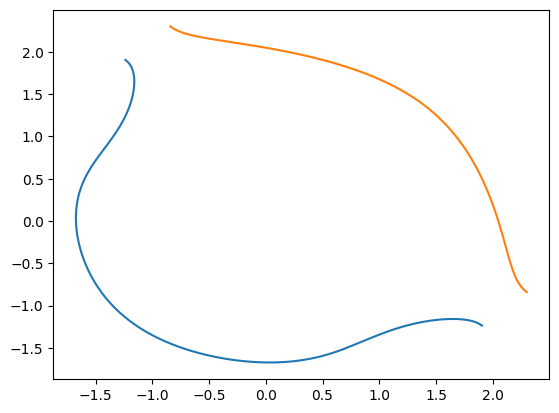

In [150]:
len(ps[0][0])

plt.plot(*ps[0][0][0], '-')
plt.plot(*ps[0][0][1], '-')